# Exercise 1 — Graduate School Admission

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")

In [2]:
DATA_URL = "https://stats.idre.ucla.edu/stat/stata/dae/binary.dta"
df = pd.read_stata(DATA_URL)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (400, 4)


,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [3]:
print(df.columns.tolist())
display(df.isnull().sum())
display(df.describe(include="all").T)

['admit', 'gre', 'gpa', 'rank']


,0
admit,0
gre,0
gpa,0
rank,0


,count,mean,std,min,25%,50%,75%,max
admit,400.0,0.317500,0.466087,0.00,0.00,0.000,1.00,1.0
gre,400.0,587.700012,115.516663,220.00,520.00,580.000,660.00,800.0
gpa,400.0,3.389900,0.380567,2.26,3.13,3.395,3.67,4.0
rank,400.0,2.485000,0.944462,1.00,2.00,2.000,3.00,4.0


In [4]:
df["admit"] = df["admit"].astype(int)
df["rank"] = df["rank"].astype(int)

X = df[["gre", "gpa", "rank"]]
y = df["admit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 320
Testing samples: 80


In [5]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Actual Admission": y_test.values,
    "Predicted Admission": y_pred,
    "Admission Probability": y_prob
})

display(results.head(10))

,Actual Admission,Predicted Admission,Admission Probability
0,0,0,0.224348
1,0,0,0.349314
2,0,0,0.310100
3,0,0,0.122872
4,1,0,0.311638
5,0,0,0.423571
6,1,0,0.320623
7,1,0,0.360030
8,0,0,0.160766
9,1,0,0.307687


In [7]:
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {auc:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.7375
ROC-AUC: 0.7218
              precision    recall  f1-score   support

           0       0.73      0.98      0.84        55
           1       0.83      0.20      0.32        25

    accuracy                           0.74        80
   macro avg       0.78      0.59      0.58        80
weighted avg       0.76      0.74      0.68        80



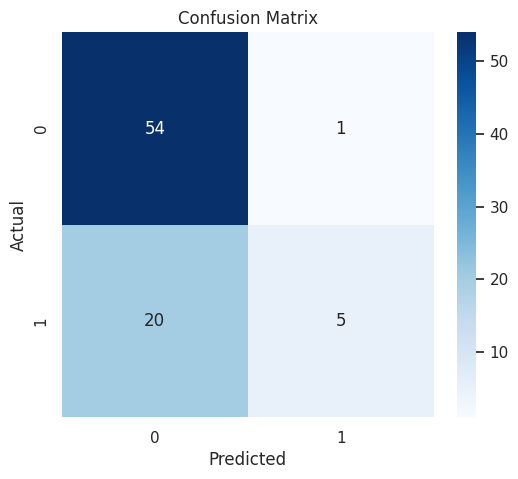

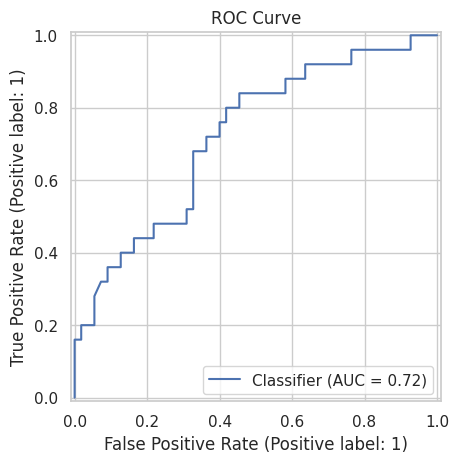

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()

In [9]:
new_student = pd.DataFrame({
    "gre": [650],
    "gpa": [3.7],
    "rank": [2]
})

probability = model.predict_proba(new_student)[0, 1]
prediction = model.predict(new_student)[0]

print(f"Admission probability: {probability:.2%}")
print("Prediction:", "Admitted" if prediction == 1 else "Not Admitted")

Admission probability: 44.23%
Prediction: Not Admitted
